# 13 - Final LOGO Meta-Blend Test

## Objective

This is the last optional experiment before freezing the final submission.

Current champion:

```text
hybrid_w_0.65
```

This notebook tests whether a lightweight Ridge meta-regressor can improve the hybrid distance predictions under Leave-One-Gravity-Out validation.

The meta-regressor uses:

- ExtraTrees prediction;
- MLP prediction;
- fixed hybrid prediction;
- simple physical inputs and physics-inspired features.

Then it tests:

```text
final_prediction = (1 - alpha) * hybrid_w_0.65 + alpha * meta_prediction
```

with:

```text
alpha in {0.0, 0.1, 0.2, 0.3, 0.4, 0.5}
```

Decision rule:

- If `alpha = 0.0` wins, keep the current hybrid submission.
- If `alpha > 0` improves LOGO clearly without degrading P95 error, consider generating a meta-blend candidate.
- If improvements are small or unstable, keep `hybrid_w_0.65`.

This notebook does **not** overwrite the official submission file by default.

## 1. Imports and paths

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
SUBMISSIONS_DIR = PROJECT_ROOT / "outputs" / "submissions"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"

for p in [SUBMISSIONS_DIR, REPORTS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward data:", FORWARD_DIR)
print("Submissions:", SUBMISSIONS_DIR)
print("Reports:", REPORTS_DIR)

Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward data: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction
Submissions: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/submissions
Reports: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports


## 2. Load data

In [2]:
input_cols = [
    "energy", "angle_rad", "coupling", "strength",
    "porosity", "gravity", "atmosphere", "shape_factor",
]

target_cols = [
    "P80", "fines_frac", "oversize_frac",
    "R95", "R50_fines", "R50_oversize",
]

fragmentation_targets = ["P80", "fines_frac", "oversize_frac"]
distance_targets = ["R95", "R50_fines", "R50_oversize"]

raw_train = pd.read_csv(FORWARD_DIR / "train.csv")[input_cols]
raw_test = pd.read_csv(FORWARD_DIR / "test.csv")[input_cols]
y = pd.read_csv(FORWARD_DIR / "train_labels.csv")[target_cols]

print("Train:", raw_train.shape)
print("Test:", raw_test.shape)
print("Targets:", y.shape)
print("Train gravity:", sorted(raw_train["gravity"].unique()))
print("Test gravity:", sorted(raw_test["gravity"].unique()))

Train: (2930, 8)
Test: (492, 8)
Targets: (2930, 6)
Train gravity: [np.float64(1.62), np.float64(3.71), np.float64(9.81)]
Test gravity: [np.float64(1.02), np.float64(1.38), np.float64(4.91), np.float64(7.03), np.float64(10.47)]


## 3. Feature engineering and model helpers

In [3]:
class PhysicsFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, use_advanced=False):
        self.use_advanced = use_advanced

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()[input_cols]
        eps = 1e-9

        X["effective_energy"] = X["energy"] * X["coupling"]
        X["log_energy"] = np.log1p(X["energy"])
        X["log_effective_energy"] = np.log1p(X["effective_energy"])

        X["sin_angle"] = np.sin(X["angle_rad"])
        X["cos_angle"] = np.cos(X["angle_rad"])
        X["tan_angle"] = np.tan(X["angle_rad"])

        X["horizontal_energy"] = X["effective_energy"] * X["cos_angle"]
        X["vertical_energy"] = X["effective_energy"] * X["sin_angle"]
        X["horizontal_energy_cos2"] = X["effective_energy"] * X["cos_angle"] ** 2

        X["energy_per_strength"] = X["energy"] / (X["strength"] + eps)
        X["effective_energy_per_strength"] = X["effective_energy"] / (X["strength"] + eps)
        X["material_resistance_index"] = X["strength"] * (1 - X["porosity"])
        X["fragmentation_index"] = X["effective_energy"] * X["porosity"] / (X["strength"] + eps)

        X["energy_per_gravity"] = X["energy"] / (X["gravity"] + eps)
        X["effective_energy_per_gravity"] = X["effective_energy"] / (X["gravity"] + eps)
        X["horizontal_energy_per_gravity"] = X["horizontal_energy"] / (X["gravity"] + eps)
        X["horizontal_cos2_energy_per_gravity"] = X["horizontal_energy_cos2"] / (X["gravity"] + eps)
        X["sqrt_effective_energy_per_gravity"] = np.sqrt(X["effective_energy_per_gravity"].clip(lower=0))
        X["sqrt_horizontal_energy_per_gravity"] = np.sqrt(X["horizontal_energy_per_gravity"].clip(lower=0))

        X["drag_proxy"] = X["atmosphere"] * X["shape_factor"]
        X["drag_per_gravity"] = X["drag_proxy"] / (X["gravity"] + eps)
        X["atmosphere_shape_energy"] = X["atmosphere"] * X["shape_factor"] * X["effective_energy"]
        X["atmosphere_per_gravity"] = X["atmosphere"] / (X["gravity"] + eps)

        X["pi_gravity_proxy"] = (X["gravity"] * X["coupling"]) / (X["energy"] + eps)
        X["pi_strength_proxy"] = X["strength"] / (X["gravity"] * X["coupling"] + eps)
        X["pi_atmosphere_proxy"] = X["atmosphere"] / (X["gravity"] * X["coupling"] + eps)

        X["porosity_regime"] = (X["porosity"] > 0.15).astype(int)
        X["strength_regime"] = (X["strength"] > 2.6).astype(int)
        X["angle_regime"] = (X["angle_rad"] > 0.95).astype(int)
        X["atm_regime"] = (X["atmosphere"] > 0.30).astype(int)

        X["regime_combo"] = (
            X["porosity_regime"] * 8
            + X["strength_regime"] * 4
            + X["angle_regime"] * 2
            + X["atm_regime"]
        )

        X["scaled_energy"] = X["effective_energy"] / (X["strength"] * np.sqrt(X["gravity"]) + eps)
        X["range_proxy"] = X["horizontal_energy_cos2"] / (X["gravity"] * X["strength"] + eps)
        X["energy_sin_angle"] = X["energy"] * X["sin_angle"]
        X["momentum_proxy"] = X["effective_energy"] * X["sin_angle"]

        if self.use_advanced:
            X["stress_ratio_compact"] = X["effective_energy"] / (X["material_resistance_index"] + eps)
            X["sqrt_effective_energy_per_strength"] = np.sqrt(X["effective_energy_per_strength"].clip(lower=0))

        return X


class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = list(columns)

    def fit(self, X, y=None):
        missing = [c for c in self.columns if c not in X.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")
        return self

    def transform(self, X):
        return X[self.columns].copy()


def clip_predictions(preds, target):
    preds = np.asarray(preds).copy()
    if target in ["fines_frac", "oversize_frac"]:
        return np.clip(preds, 0, 1)
    return np.clip(preds, 0, None)


def regression_metrics(y_true, y_pred, target_name=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    abs_err = np.abs(y_pred - y_true)

    out = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "P90_AE": np.percentile(abs_err, 90),
        "P95_AE": np.percentile(abs_err, 95),
        "Bias": float(np.mean(y_pred - y_true)),
    }

    if target_name is not None:
        out["normalized_MAE"] = out["MAE"] / (y[target_name].std() + 1e-9)

    return out


def build_extratrees(random_state=42, n_estimators=800):
    return ExtraTreesRegressor(
        n_estimators=n_estimators,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1,
    )


def build_mlp(random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=1200,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=40,
            random_state=random_state,
        )),
    ])

## 4. Feature sets

In [4]:
raw_features = input_cols.copy()

fragmentation_features_v1 = raw_features + [
    "effective_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_strength", "effective_energy_per_strength",
    "material_resistance_index", "fragmentation_index",
    "drag_proxy", "atmosphere_shape_energy",
    "pi_strength_proxy", "pi_atmosphere_proxy", "scaled_energy",
    "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

fragmentation_features_v2 = fragmentation_features_v1 + [
    "stress_ratio_compact",
    "sqrt_effective_energy_per_strength",
]

distance_features_v1 = raw_features + [
    "effective_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_gravity", "effective_energy_per_gravity",
    "horizontal_energy_per_gravity", "sqrt_effective_energy_per_gravity",
    "sqrt_horizontal_energy_per_gravity",
    "drag_proxy", "drag_per_gravity",
    "atmosphere_shape_energy", "atmosphere_per_gravity",
    "pi_gravity_proxy", "pi_atmosphere_proxy",
    "scaled_energy", "range_proxy",
    "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

meta_physics_features = [
    "energy", "angle_rad", "coupling", "strength", "porosity", "gravity", "atmosphere", "shape_factor",
    "effective_energy", "horizontal_energy", "horizontal_energy_cos2",
    "effective_energy_per_gravity", "horizontal_cos2_energy_per_gravity",
    "sqrt_effective_energy_per_gravity", "sqrt_horizontal_energy_per_gravity",
    "drag_proxy", "range_proxy", "scaled_energy",
]


final_target_config = {
    "P80": {"feature_version": "v2", "features": fragmentation_features_v2},
    "fines_frac": {"feature_version": "v2", "features": fragmentation_features_v2},
    "oversize_frac": {"feature_version": "v2", "features": fragmentation_features_v2},
    "R95": {"feature_version": "v1", "features": distance_features_v1},
    "R50_fines": {"feature_version": "v1", "features": distance_features_v1},
    "R50_oversize": {"feature_version": "v1", "features": distance_features_v1},
}


def build_target_et_pipeline(target, random_state=42, n_estimators=800):
    cfg = final_target_config[target]

    return Pipeline([
        ("features", PhysicsFeatureEngineer(use_advanced=cfg["feature_version"] == "v2")),
        ("select", ColumnSelector(cfg["features"])),
        ("model", build_extratrees(random_state=random_state, n_estimators=n_estimators)),
    ])


def build_feature_matrix_for_target(X_raw, target):
    cfg = final_target_config[target]
    X_fe = PhysicsFeatureEngineer(use_advanced=cfg["feature_version"] == "v2").fit_transform(X_raw)
    return X_fe[cfg["features"]].copy()


def build_meta_feature_matrix(X_raw, et_pred, mlp_pred, hybrid_pred):
    X_fe = PhysicsFeatureEngineer(use_advanced=True).fit_transform(X_raw)
    available_meta_features = [c for c in meta_physics_features if c in X_fe.columns]

    meta_X = pd.DataFrame(index=X_fe.index)
    meta_X["et_pred"] = et_pred
    meta_X["mlp_pred"] = mlp_pred
    meta_X["hybrid_pred"] = hybrid_pred
    meta_X["mlp_minus_et"] = mlp_pred - et_pred
    meta_X["hybrid_minus_et"] = hybrid_pred - et_pred

    for col in available_meta_features:
        meta_X[col] = X_fe[col].values

    return meta_X


display(pd.DataFrame([
    {"feature_group": "fragmentation_v2", "n_features": len(fragmentation_features_v2)},
    {"feature_group": "distance_v1", "n_features": len(distance_features_v1)},
    {"feature_group": "meta_physics_features", "n_features": len(meta_physics_features)},
]))

,feature_group,n_features
0,fragmentation_v2,32
1,distance_v1,34
2,meta_physics_features,18


## 5. Nested OOF meta-features inside each LOGO training fold

In [5]:
def internal_oof_meta_training_data(X_train_raw, y_train_target, target, random_state=42, n_splits=5, n_estimators=500):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    et_oof = np.zeros(len(X_train_raw))
    mlp_oof = np.zeros(len(X_train_raw))
    hybrid_oof = np.zeros(len(X_train_raw))

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train_raw), start=1):
        X_tr = X_train_raw.iloc[tr_idx].reset_index(drop=True)
        X_va = X_train_raw.iloc[va_idx].reset_index(drop=True)

        y_tr = y_train_target.iloc[tr_idx].reset_index(drop=True)

        et_pipe = build_target_et_pipeline(
            target,
            random_state=random_state + fold,
            n_estimators=n_estimators,
        )
        et_pipe.fit(X_tr, y_tr)
        et_pred = et_pipe.predict(X_va)

        X_tr_target = build_feature_matrix_for_target(X_tr, target)
        X_va_target = build_feature_matrix_for_target(X_va, target)

        mlp = build_mlp(random_state=random_state + 100 + fold)
        mlp.fit(X_tr_target, y_tr)
        mlp_pred = mlp.predict(X_va_target)

        hybrid_pred = (1 - 0.65) * et_pred + 0.65 * mlp_pred

        et_oof[va_idx] = clip_predictions(et_pred, target)
        mlp_oof[va_idx] = clip_predictions(mlp_pred, target)
        hybrid_oof[va_idx] = clip_predictions(hybrid_pred, target)

    meta_X = build_meta_feature_matrix(
        X_train_raw.reset_index(drop=True),
        et_oof,
        mlp_oof,
        hybrid_oof,
    )

    return meta_X, et_oof, mlp_oof, hybrid_oof


def fit_base_models_for_logo_train(X_train_raw, y_train_target, target, random_state=42, n_estimators=800):
    et_pipe = build_target_et_pipeline(
        target,
        random_state=random_state,
        n_estimators=n_estimators,
    )
    et_pipe.fit(X_train_raw, y_train_target)

    X_train_target = build_feature_matrix_for_target(X_train_raw, target)

    mlp = build_mlp(random_state=random_state + 1000)
    mlp.fit(X_train_target, y_train_target)

    return et_pipe, mlp


def predict_base_models_for_logo_valid(et_pipe, mlp, X_valid_raw, target):
    et_pred = clip_predictions(et_pipe.predict(X_valid_raw), target)

    X_valid_target = build_feature_matrix_for_target(X_valid_raw, target)
    mlp_pred = clip_predictions(mlp.predict(X_valid_target), target)

    hybrid_pred = clip_predictions((1 - 0.65) * et_pred + 0.65 * mlp_pred, target)

    return et_pred, mlp_pred, hybrid_pred

## 6. Leave-One-Gravity-Out meta-blend test

In [6]:
ALPHAS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
LOGO_N_ESTIMATORS = 800
INTERNAL_N_ESTIMATORS = 500

oof_predictions = {
    "hybrid_w_0.65": pd.DataFrame(index=y.index, columns=distance_targets, dtype=float),
    "meta_ridge": pd.DataFrame(index=y.index, columns=distance_targets, dtype=float),
}

for alpha in ALPHAS:
    oof_predictions[f"meta_blend_alpha_{alpha:.1f}"] = pd.DataFrame(index=y.index, columns=distance_targets, dtype=float)

fold_rows = []

for logo_fold, heldout_gravity in enumerate(sorted(raw_train["gravity"].unique()), start=1):
    valid_idx = raw_train.index[raw_train["gravity"] == heldout_gravity].tolist()
    train_idx = raw_train.index[raw_train["gravity"] != heldout_gravity].tolist()

    X_train_logo = raw_train.loc[train_idx].reset_index(drop=True)
    X_valid_logo = raw_train.loc[valid_idx].reset_index(drop=True)
    y_train_logo = y.loc[train_idx].reset_index(drop=True)

    print(f"LOGO fold {logo_fold}: heldout gravity={heldout_gravity}, train={len(train_idx)}, valid={len(valid_idx)}")

    for target_i, target in enumerate(distance_targets):
        print(f"  Target: {target}")

        meta_X_train, et_oof, mlp_oof, hybrid_oof = internal_oof_meta_training_data(
            X_train_logo,
            y_train_logo[target],
            target,
            random_state=42 + logo_fold * 100 + target_i,
            n_splits=5,
            n_estimators=INTERNAL_N_ESTIMATORS,
        )

        meta_model = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=10.0)),
        ])
        meta_model.fit(meta_X_train, y_train_logo[target])

        et_pipe, mlp = fit_base_models_for_logo_train(
            X_train_logo,
            y_train_logo[target],
            target,
            random_state=42 + logo_fold * 1000 + target_i,
            n_estimators=LOGO_N_ESTIMATORS,
        )

        et_valid, mlp_valid, hybrid_valid = predict_base_models_for_logo_valid(
            et_pipe,
            mlp,
            X_valid_logo,
            target,
        )

        meta_X_valid = build_meta_feature_matrix(
            X_valid_logo,
            et_valid,
            mlp_valid,
            hybrid_valid,
        )

        meta_valid = clip_predictions(meta_model.predict(meta_X_valid), target)

        oof_predictions["hybrid_w_0.65"].loc[valid_idx, target] = hybrid_valid
        oof_predictions["meta_ridge"].loc[valid_idx, target] = meta_valid

        for alpha in ALPHAS:
            blend = clip_predictions((1 - alpha) * hybrid_valid + alpha * meta_valid, target)
            oof_predictions[f"meta_blend_alpha_{alpha:.1f}"].loc[valid_idx, target] = blend

    fold_rows.append({
        "logo_fold": logo_fold,
        "heldout_gravity": heldout_gravity,
        "n_train": len(train_idx),
        "n_valid": len(valid_idx),
    })

fold_info = pd.DataFrame(fold_rows)
display(fold_info)

LOGO fold 1: heldout gravity=1.62, train=1940, valid=990
  Target: R95
  Target: R50_fines
  Target: R50_oversize
LOGO fold 2: heldout gravity=3.71, train=1930, valid=1000
  Target: R95
  Target: R50_fines
  Target: R50_oversize
LOGO fold 3: heldout gravity=9.81, train=1990, valid=940
  Target: R95
  Target: R50_fines
  Target: R50_oversize


,logo_fold,heldout_gravity,n_train,n_valid
0,1,1.62,1940,990
1,2,3.71,1930,1000
2,3,9.81,1990,940


## 7. Evaluate strategies

In [7]:
metric_rows = []

for strategy, pred_df in oof_predictions.items():
    for target in distance_targets:
        metrics = regression_metrics(y[target], pred_df[target], target_name=target)
        metrics["strategy"] = strategy
        metrics["target"] = target
        metric_rows.append(metrics)

metrics_df = pd.DataFrame(metric_rows)

display(
    metrics_df
    .sort_values(["target", "normalized_MAE"])
    [["target", "strategy", "MAE", "RMSE", "R2", "P95_AE", "Bias", "normalized_MAE"]]
)

summary_df = (
    metrics_df
    .groupby("strategy")
    .agg(
        mean_norm_MAE=("normalized_MAE", "mean"),
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_R2=("R2", "mean"),
        mean_P95_AE=("P95_AE", "mean"),
        mean_abs_bias=("Bias", lambda s: np.mean(np.abs(s))),
    )
    .reset_index()
    .sort_values("mean_norm_MAE")
)

display(summary_df)

metrics_df.to_csv(REPORTS_DIR / "13_meta_blend_logo_metrics_by_target.csv", index=False)
summary_df.to_csv(REPORTS_DIR / "13_meta_blend_logo_summary.csv", index=False)

,target,strategy,MAE,RMSE,R2,P95_AE,Bias,normalized_MAE
1,R50_fines,hybrid_w_0.65,95.641557,138.624526,0.684652,315.583003,-31.333768,0.387372
7,R50_fines,meta_blend_alpha_0.0,95.641557,138.624526,0.684652,315.583003,-31.333768,0.387372
10,R50_fines,meta_blend_alpha_0.1,96.546225,140.971514,0.673883,319.795626,-33.711761,0.391036
13,R50_fines,meta_blend_alpha_0.2,98.480370,143.590664,0.661653,323.311475,-36.089754,0.398870
16,R50_fines,meta_blend_alpha_0.3,101.808076,146.467376,0.647960,326.840355,-38.467747,0.412348
19,R50_fines,meta_blend_alpha_0.4,106.456832,149.586791,0.632805,332.825824,-40.845739,0.431176
22,R50_fines,meta_blend_alpha_0.5,111.988657,152.934059,0.616188,335.516986,-43.223732,0.453581
4,R50_fines,meta_ridge,141.719344,172.593323,0.511169,352.438839,-55.113697,0.573998
14,R50_oversize,meta_blend_alpha_0.2,41.058108,64.668981,0.644217,143.415107,-18.265548,0.378636
17,R50_oversize,meta_blend_alpha_0.3,41.227754,65.417278,0.635936,144.973816,-20.428404,0.380200


,strategy,mean_norm_MAE,mean_MAE,mean_RMSE,mean_R2,mean_P95_AE,mean_abs_bias
2,meta_blend_alpha_0.1,0.356645,69.627995,106.799512,0.696974,238.895935,24.542595
3,meta_blend_alpha_0.2,0.357763,70.031895,108.073162,0.689826,241.334092,26.983777
1,meta_blend_alpha_0.0,0.358686,69.867240,105.725707,0.702889,235.762832,22.101412
0,hybrid_w_0.65,0.358686,69.867240,105.725707,0.702889,235.762832,22.101412
4,meta_blend_alpha_0.3,0.363537,71.378858,109.539600,0.681446,243.598939,29.424960
5,meta_blend_alpha_0.4,0.374455,73.727627,111.191198,0.671832,246.869672,31.866143
6,meta_blend_alpha_0.5,0.389565,76.864454,113.019908,0.660986,249.320758,34.307326
7,meta_ridge,0.481588,95.371860,124.526200,0.588260,262.540905,46.513241


## 8. Compare against current champion

In [8]:
champion = metrics_df[metrics_df["strategy"] == "hybrid_w_0.65"].set_index("target")

delta_rows = []

for strategy in metrics_df["strategy"].unique():
    if strategy == "hybrid_w_0.65":
        continue

    temp = metrics_df[metrics_df["strategy"] == strategy].set_index("target")

    for target in distance_targets:
        delta_rows.append({
            "strategy": strategy,
            "target": target,
            "MAE_delta_vs_hybrid": temp.loc[target, "MAE"] - champion.loc[target, "MAE"],
            "P95_AE_delta_vs_hybrid": temp.loc[target, "P95_AE"] - champion.loc[target, "P95_AE"],
            "norm_MAE_delta_vs_hybrid": temp.loc[target, "normalized_MAE"] - champion.loc[target, "normalized_MAE"],
        })

delta_df = pd.DataFrame(delta_rows)

display(delta_df.sort_values(["strategy", "target"]))
delta_df.to_csv(REPORTS_DIR / "13_meta_blend_delta_vs_hybrid.csv", index=False)

,strategy,target,MAE_delta_vs_hybrid,P95_AE_delta_vs_hybrid,norm_MAE_delta_vs_hybrid
4,meta_blend_alpha_0.0,R50_fines,0.000000,0.000000,0.000000
5,meta_blend_alpha_0.0,R50_oversize,0.000000,0.000000,0.000000
3,meta_blend_alpha_0.0,R95,0.000000,0.000000,0.000000
7,meta_blend_alpha_0.1,R50_fines,0.904668,4.212623,0.003664
8,meta_blend_alpha_0.1,R50_oversize,-0.593807,2.559868,-0.005476
6,meta_blend_alpha_0.1,R95,-1.028595,2.626819,-0.004312
10,meta_blend_alpha_0.2,R50_fines,2.838814,7.728473,0.011498
11,meta_blend_alpha_0.2,R50_oversize,-0.882254,4.181848,-0.008136
9,meta_blend_alpha_0.2,R95,-1.462594,4.803458,-0.006131
13,meta_blend_alpha_0.3,R50_fines,6.166520,11.257353,0.024976


## 9. Gravity breakdown

,target,heldout_gravity,strategy,MAE,P95_AE,Bias,normalized_MAE
1,R50_fines,1.62,hybrid_w_0.65,185.931434,403.829208,-180.985652,0.753068
19,R50_fines,1.62,meta_blend_alpha_0.0,185.931434,403.829208,-180.985652,0.753068
28,R50_fines,1.62,meta_blend_alpha_0.1,189.377264,407.125836,-185.061571,0.767024
37,R50_fines,1.62,meta_blend_alpha_0.2,192.856279,409.893038,-189.137490,0.781115
46,R50_fines,1.62,meta_blend_alpha_0.3,196.422540,412.746710,-193.213410,0.795559
...,...,...,...,...,...,...,...
33,R95,9.81,meta_blend_alpha_0.1,15.605072,44.283525,12.283930,0.065418
69,R95,9.81,meta_blend_alpha_0.5,18.343935,45.081896,-17.599755,0.076900
6,R95,9.81,hybrid_w_0.65,21.328562,55.044928,19.754851,0.089412
24,R95,9.81,meta_blend_alpha_0.0,21.328562,55.044928,19.754851,0.089412


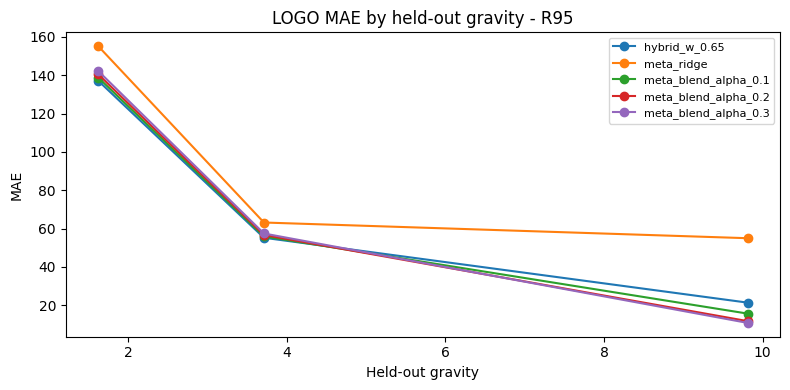

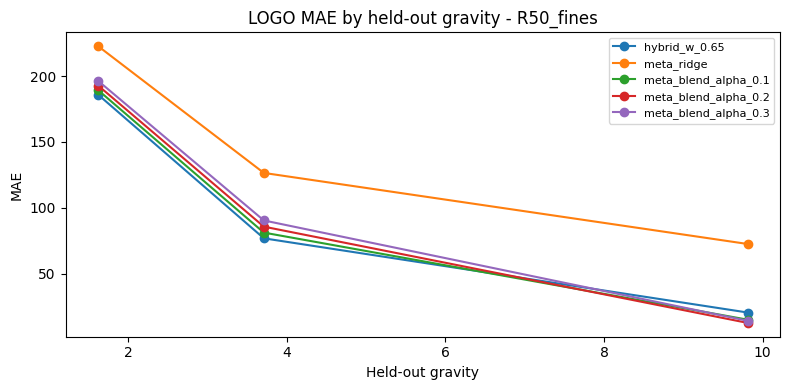

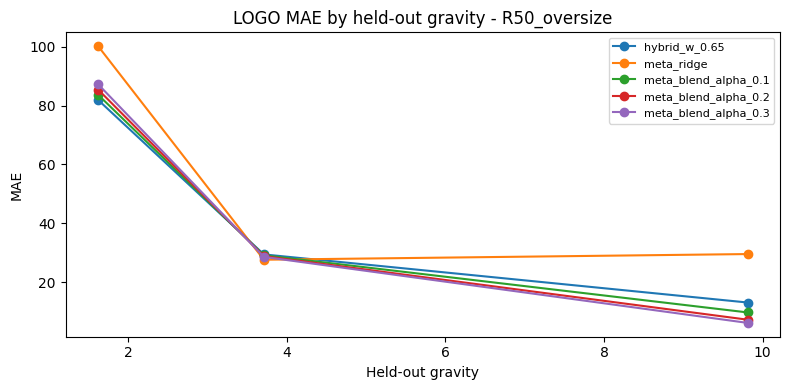

In [9]:
gravity_rows = []

for strategy, pred_df in oof_predictions.items():
    for heldout_gravity in sorted(raw_train["gravity"].unique()):
        mask = raw_train["gravity"] == heldout_gravity

        for target in distance_targets:
            metrics = regression_metrics(
                y.loc[mask, target],
                pred_df.loc[mask, target],
                target_name=target,
            )

            metrics["strategy"] = strategy
            metrics["heldout_gravity"] = heldout_gravity
            metrics["target"] = target
            gravity_rows.append(metrics)

gravity_df = pd.DataFrame(gravity_rows)

display(
    gravity_df
    .sort_values(["target", "heldout_gravity", "MAE"])
    [["target", "heldout_gravity", "strategy", "MAE", "P95_AE", "Bias", "normalized_MAE"]]
)

gravity_df.to_csv(REPORTS_DIR / "13_meta_blend_gravity_breakdown.csv", index=False)

for target in distance_targets:
    plt.figure(figsize=(8, 4))

    temp = gravity_df[gravity_df["target"] == target]

    for strategy in ["hybrid_w_0.65", "meta_ridge", "meta_blend_alpha_0.1", "meta_blend_alpha_0.2", "meta_blend_alpha_0.3"]:
        if strategy in temp["strategy"].unique():
            t = temp[temp["strategy"] == strategy].sort_values("heldout_gravity")
            plt.plot(t["heldout_gravity"], t["MAE"], marker="o", label=strategy)

    plt.title(f"LOGO MAE by held-out gravity - {target}")
    plt.xlabel("Held-out gravity")
    plt.ylabel("MAE")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 10. Decision table

In [10]:
best_strategy = summary_df.iloc[0]["strategy"]
best_mean_norm = summary_df.iloc[0]["mean_norm_MAE"]

champion_mean_norm = summary_df.loc[
    summary_df["strategy"] == "hybrid_w_0.65",
    "mean_norm_MAE"
].iloc[0]

decision_summary = pd.DataFrame([{
    "best_strategy": best_strategy,
    "best_mean_norm_MAE": best_mean_norm,
    "champion_strategy": "hybrid_w_0.65",
    "champion_mean_norm_MAE": champion_mean_norm,
    "improvement_vs_champion": best_mean_norm - champion_mean_norm,
}])

display(decision_summary)

if best_strategy != "hybrid_w_0.65":
    best_target_metrics = metrics_df[metrics_df["strategy"] == best_strategy].set_index("target")
    hybrid_target_metrics = metrics_df[metrics_df["strategy"] == "hybrid_w_0.65"].set_index("target")

    target_decision = []
    for target in distance_targets:
        target_decision.append({
            "target": target,
            "best_strategy": best_strategy,
            "MAE_delta_vs_hybrid": best_target_metrics.loc[target, "MAE"] - hybrid_target_metrics.loc[target, "MAE"],
            "P95_AE_delta_vs_hybrid": best_target_metrics.loc[target, "P95_AE"] - hybrid_target_metrics.loc[target, "P95_AE"],
            "improves_MAE": best_target_metrics.loc[target, "MAE"] < hybrid_target_metrics.loc[target, "MAE"],
            "improves_P95_AE": best_target_metrics.loc[target, "P95_AE"] < hybrid_target_metrics.loc[target, "P95_AE"],
        })

    target_decision = pd.DataFrame(target_decision)
    display(target_decision)

    n_mae_improved = int(target_decision["improves_MAE"].sum())
    n_p95_improved = int(target_decision["improves_P95_AE"].sum())
else:
    target_decision = pd.DataFrame()
    n_mae_improved = 0
    n_p95_improved = 0

print("Best strategy:", best_strategy)
print("Mean normalized MAE improvement vs hybrid:", best_mean_norm - champion_mean_norm)

if best_strategy == "hybrid_w_0.65":
    print("Decision: keep current hybrid_w_0.65 final submission.")
elif (best_mean_norm < champion_mean_norm) and (n_mae_improved >= 2) and (n_p95_improved >= 2):
    print("Decision: meta-blend is a serious candidate. Generate candidate file and compare test distribution before replacing final submission.")
else:
    print("Decision: improvement is not strong enough. Keep current hybrid_w_0.65 final submission.")

decision_summary.to_csv(REPORTS_DIR / "13_meta_blend_decision_summary.csv", index=False)
if len(target_decision):
    target_decision.to_csv(REPORTS_DIR / "13_meta_blend_target_decision.csv", index=False)

,best_strategy,best_mean_norm_MAE,champion_strategy,champion_mean_norm_MAE,improvement_vs_champion
0,meta_blend_alpha_0.1,0.356645,hybrid_w_0.65,0.358686,-0.002041


,target,best_strategy,MAE_delta_vs_hybrid,P95_AE_delta_vs_hybrid,improves_MAE,improves_P95_AE
0,R95,meta_blend_alpha_0.1,-1.028595,2.626819,True,False
1,R50_fines,meta_blend_alpha_0.1,0.904668,4.212623,False,False
2,R50_oversize,meta_blend_alpha_0.1,-0.593807,2.559868,True,False


Best strategy: meta_blend_alpha_0.1
Mean normalized MAE improvement vs hybrid: -0.002041306308684765
Decision: improvement is not strong enough. Keep current hybrid_w_0.65 final submission.


## 11. Optional test-set candidate generation

In [11]:
CREATE_META_BLEND_CANDIDATE = False

SELECTED_ALPHA = 0.1  # Change only if LOGO results support another alpha.

def train_full_meta_blend_for_target(target, selected_alpha=0.1):
    meta_X_train, et_oof, mlp_oof, hybrid_oof = internal_oof_meta_training_data(
        raw_train,
        y[target],
        target,
        random_state=2026,
        n_splits=5,
        n_estimators=INTERNAL_N_ESTIMATORS,
    )

    meta_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0)),
    ])
    meta_model.fit(meta_X_train, y[target])

    et_pipe, mlp = fit_base_models_for_logo_train(
        raw_train,
        y[target],
        target,
        random_state=2026,
        n_estimators=LOGO_N_ESTIMATORS,
    )

    et_test, mlp_test, hybrid_test = predict_base_models_for_logo_valid(
        et_pipe,
        mlp,
        raw_test,
        target,
    )

    meta_X_test = build_meta_feature_matrix(
        raw_test,
        et_test,
        mlp_test,
        hybrid_test,
    )

    meta_test = clip_predictions(meta_model.predict(meta_X_test), target)
    final_test = clip_predictions((1 - selected_alpha) * hybrid_test + selected_alpha * meta_test, target)

    return final_test, hybrid_test, meta_test


if CREATE_META_BLEND_CANDIDATE:
    official_path = SUBMISSIONS_DIR / "prediction_submission.csv"
    candidate = pd.read_csv(official_path)

    for target in distance_targets:
        final_test, hybrid_test, meta_test = train_full_meta_blend_for_target(
            target,
            selected_alpha=SELECTED_ALPHA,
        )
        candidate[target] = final_test

    candidate_path = SUBMISSIONS_DIR / f"prediction_submission_meta_blend_alpha_{SELECTED_ALPHA:.1f}.csv"
    candidate.to_csv(candidate_path, index=False)

    print("Saved candidate:", candidate_path)
    display(candidate.head())
    display(candidate[target_cols].describe().T)
else:
    print("Candidate generation disabled.")
    print("This notebook is a final test. Keep hybrid_w_0.65 unless LOGO improvement is clear.")

Candidate generation disabled.
This notebook is a final test. Keep hybrid_w_0.65 unless LOGO improvement is clear.


## 12. Final note

This notebook is the final optional experiment.

If the meta-blend does not clearly beat `hybrid_w_0.65`, the project should be frozen and the video/presentation preparation should start.